In [1]:
!pip install -q geemap earthengine-api
import ee
ee.Authenticate()
ee.Initialize(project='urbanpulse-blr')
print("Earth Engine ready!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 44.5 MB/s eta 0:00:00
Earth Engine ready!


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


In [2]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

import geemap

districts = ee.FeatureCollection('FAO/GAUL/2015/level2')

# Keep only Bangalore Urban (the city area)
blr = districts.filter(ee.Filter.eq('ADM1_NAME', 'Karnataka')) \
               .filter(ee.Filter.eq('ADM2_NAME', 'Bangalore Urban'))

roi = blr.geometry()   # our Region of Interest, used in every later step

Map = geemap.Map(basemap='Esri.WorldImagery')   # Google satellite background
Map.centerObject(blr, 10)
Map.addLayer(blr.style(color='red', fillColor='00000000', width=2), {}, 'Bangalore Urban')
Map

Map(center=[12.94224621144063, 77.58684946919362], controls=(WidgetControl(options=['position', 'transparent_b…

In [3]:
# 1. Remove clouds and cloud shadows
def mask_clouds(img):
    qa = img.select('QA_PIXEL')
    mask = qa.bitwiseAnd(1 << 3).eq(0).And(qa.bitwiseAnd(1 << 4).eq(0))
    return img.updateMask(mask)

# 2. Convert the thermal band to temperature in °C
def add_lst(img):
    lst = img.select('ST_B10').multiply(0.00341802).add(149.0) \
             .subtract(273.15).rename('LST')
    return img.addBands(lst)

# 3. Load Landsat 8 + 9 for summer 2024
landsat = (ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')
           .merge(ee.ImageCollection('LANDSAT/LC08/C02/T1_L2'))
           .filterBounds(roi)
           .filterDate('2024-03-01', '2024-05-31')
           .filter(ee.Filter.lt('CLOUD_COVER', 30))
           .map(mask_clouds)
           .map(add_lst))

print('Images used:', landsat.size().getInfo())

lst_2024 = landsat.select('LST').median().clip(roi)

# 4. Summary statistics
stats = lst_2024.reduceRegion(
    reducer=ee.Reducer.minMax().combine(ee.Reducer.mean(), sharedInputs=True),
    geometry=roi, scale=100, maxPixels=1e9)
print('LST stats (°C):', stats.getInfo())

# 5. Map it
vis = {'min': 25, 'max': 45,
       'palette': ['blue', 'cyan', 'green', 'yellow', 'orange', 'red']}

Map = geemap.Map(basemap='Esri.WorldImagery', center=[12.97, 77.59], zoom=10)
Map.addLayer(lst_2024, vis, 'LST Summer 2024 (°C)')
Map.addLayer(blr.style(color='white', fillColor='00000000', width=2), {}, 'Boundary')
Map.add_colorbar(vis, label='Land Surface Temperature (°C)')
Map

Images used: 9
LST stats (°C): {'LST_max': 54.71840462, 'LST_mean': 42.37349450646532, 'LST_min': 27.743390780000027}


Map(center=[12.97, 77.59], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

In [4]:
# Reusable function: summer LST for any year
def get_lst(year):
    col = (ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')
           .merge(ee.ImageCollection('LANDSAT/LC08/C02/T1_L2'))
           .filterBounds(roi)
           .filterDate(f'{year}-03-01', f'{year}-05-31')
           .filter(ee.Filter.lt('CLOUD_COVER', 30))
           .map(mask_clouds)
           .map(add_lst))
    print(year, '- images used:', col.size().getInfo())
    return col.select('LST').median().clip(roi)

lst_2014 = get_lst(2014)
lst_2024 = get_lst(2024)

# Change in temperature
lst_change = lst_2024.subtract(lst_2014).rename('LST_change')

def mean_temp(img):
    return img.reduceRegion(ee.Reducer.mean(), roi, 100, maxPixels=1e9).getInfo()

print('Mean LST 2014:', mean_temp(lst_2014))
print('Mean LST 2024:', mean_temp(lst_2024))
print('Mean change  :', mean_temp(lst_change))

# Better colour scale
vis = {'min': 30, 'max': 50,
       'palette': ['blue', 'cyan', 'green', 'yellow', 'orange', 'red']}
change_vis = {'min': -5, 'max': 5, 'palette': ['blue', 'white', 'red']}

Map = geemap.Map(basemap='Esri.WorldImagery', center=[12.97, 77.59], zoom=10)
Map.addLayer(lst_2014, vis, 'LST 2014')
Map.addLayer(lst_2024, vis, 'LST 2024')
Map.addLayer(lst_change, change_vis, 'Change 2014 to 2024')
Map.addLayer(blr.style(color='white', fillColor='00000000', width=2), {}, 'Boundary')
Map.add_colorbar(vis, label='LST (°C)')
Map

2014 - images used: 5
2024 - images used: 9
Mean LST 2014: {'LST': 41.86738049056253}
Mean LST 2024: {'LST': 42.37349450646532}
Mean change  : {'LST_change': 0.5061140159027657}


Map(center=[12.97, 77.59], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

Pixels sampled: 5000
       LST  NDBI  NDVI
LST   1.00  0.73 -0.25
NDBI  0.73  1.00 -0.59
NDVI -0.25 -0.59  1.00


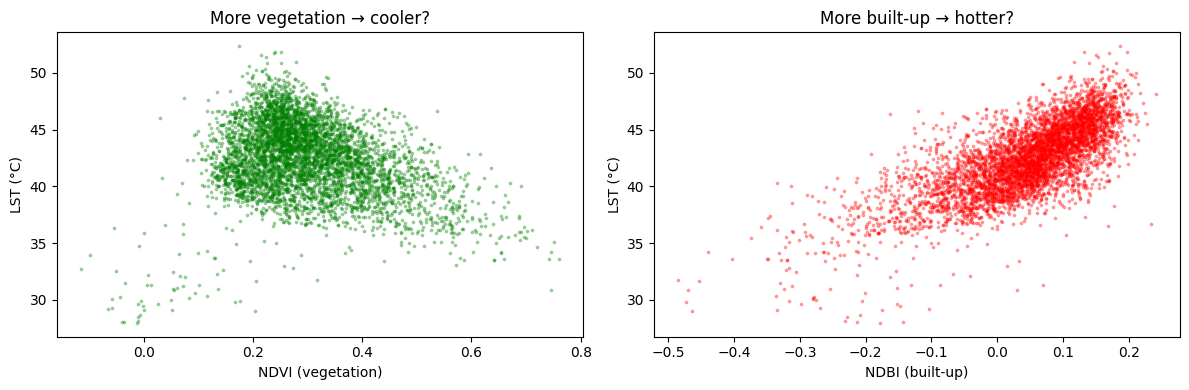

Map(center=[12.97, 77.59], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

In [5]:
import matplotlib.pyplot as plt

# Add vegetation (NDVI) and built-up (NDBI) indices
def add_indices(img):
    sr = img.select(['SR_B4', 'SR_B5', 'SR_B6']).multiply(0.0000275).add(-0.2)
    ndvi = sr.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')
    ndbi = sr.normalizedDifference(['SR_B6', 'SR_B5']).rename('NDBI')
    return img.addBands(ndvi).addBands(ndbi)

def get_composite(year):
    col = (ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')
           .merge(ee.ImageCollection('LANDSAT/LC08/C02/T1_L2'))
           .filterBounds(roi)
           .filterDate(f'{year}-03-01', f'{year}-05-31')
           .filter(ee.Filter.lt('CLOUD_COVER', 30))
           .map(mask_clouds)
           .map(add_lst)
           .map(add_indices))
    return col.select(['LST', 'NDVI', 'NDBI']).median().clip(roi)

comp_2024 = get_composite(2024)

# Sample 5000 random pixels across the city
samples = comp_2024.sample(region=roi, scale=100, numPixels=5000,
                           seed=42, geometries=False)
df = geemap.ee_to_df(samples).dropna()
print('Pixels sampled:', len(df))
print(df.corr().round(2))

# Scatter plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(df['NDVI'], df['LST'], s=3, alpha=0.3, color='green')
axes[0].set_xlabel('NDVI (vegetation)'); axes[0].set_ylabel('LST (°C)')
axes[0].set_title('More vegetation → cooler?')
axes[1].scatter(df['NDBI'], df['LST'], s=3, alpha=0.3, color='red')
axes[1].set_xlabel('NDBI (built-up)'); axes[1].set_ylabel('LST (°C)')
axes[1].set_title('More built-up → hotter?')
plt.tight_layout(); plt.show()

# Show the index maps
Map = geemap.Map(basemap='Esri.WorldImagery', center=[12.97, 77.59], zoom=10)
Map.addLayer(comp_2024.select('NDVI'), {'min': 0, 'max': 0.6,
             'palette': ['brown', 'yellow', 'green']}, 'NDVI 2024')
Map.addLayer(comp_2024.select('NDBI'), {'min': -0.3, 'max': 0.3,
             'palette': ['blue', 'white', 'red']}, 'NDBI 2024')
Map

 Land cover  Mean LST (°C)  Pixels
  Grassland          44.48  214783
   Cropland          44.45  747854
Bare/sparse          42.75   30314
  Shrubland          42.56  318361
   Built-up          41.05  742858
 Tree cover          40.25  427217
      Water          34.57   23143
    Wetland          33.33     666


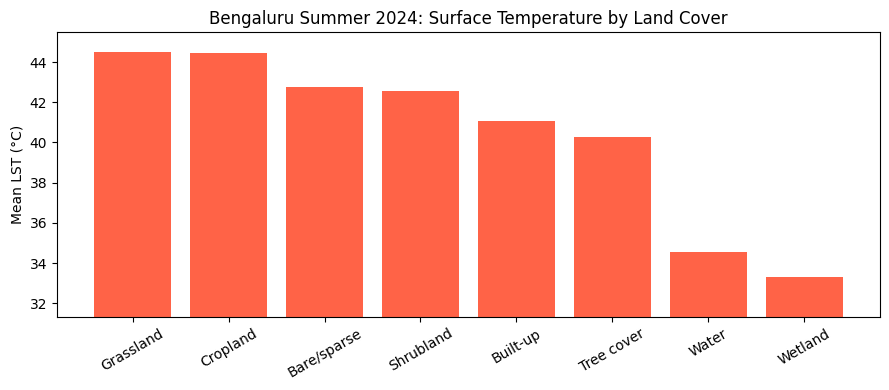

In [6]:
import pandas as pd

# ESA WorldCover land cover (2021, 10 m)
wc = ee.ImageCollection('ESA/WorldCover/v200').first().clip(roi).rename('class')

class_names = {10: 'Tree cover', 20: 'Shrubland', 30: 'Grassland',
               40: 'Cropland', 50: 'Built-up', 60: 'Bare/sparse',
               80: 'Water', 90: 'Wetland'}

# Mean LST per land cover class
lst = comp_2024.select('LST')
result = lst.addBands(wc).reduceRegion(
    reducer=ee.Reducer.mean().combine(ee.Reducer.count(), sharedInputs=True)
                      .group(groupField=1, groupName='class'),
    geometry=roi, scale=30, maxPixels=1e10).getInfo()

rows = [{'Land cover': class_names.get(g['class'], g['class']),
         'Mean LST (°C)': round(g['mean'], 2),
         'Pixels': g['count']} for g in result['groups']]
lc_df = pd.DataFrame(rows).sort_values('Mean LST (°C)', ascending=False)
print(lc_df.to_string(index=False))

# Bar chart
plt.figure(figsize=(9, 4))
plt.bar(lc_df['Land cover'], lc_df['Mean LST (°C)'], color='tomato')
plt.ylabel('Mean LST (°C)')
plt.title('Bengaluru Summer 2024: Surface Temperature by Land Cover')
plt.ylim(lc_df['Mean LST (°C)'].min() - 2, lc_df['Mean LST (°C)'].max() + 1)
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

 Land cover  Day LST (°C)  Night LST (°C)
   Built-up         36.40           25.88
 Tree cover         36.87           25.08
      Water         36.42           25.05
Bare/sparse         37.30           24.67
  Shrubland         37.58           24.60
  Grassland         38.14           24.38
   Cropland         38.02           24.36
    Wetland         35.53           24.25


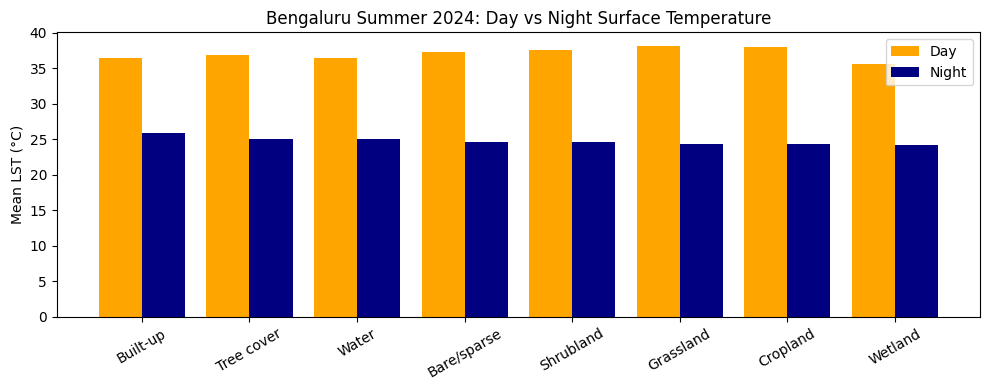

In [7]:
# MODIS land surface temperature (day + night), summer 2024
modis = (ee.ImageCollection('MODIS/061/MOD11A2')
         .filterDate('2024-03-01', '2024-05-31')
         .select(['LST_Day_1km', 'LST_Night_1km']))

modis_c = modis.median().multiply(0.02).subtract(273.15).clip(roi)

res = modis_c.addBands(wc).reduceRegion(
    reducer=ee.Reducer.mean().repeat(2).group(groupField=2, groupName='class'),
    geometry=roi, scale=100, maxPixels=1e10).getInfo()

rows = [{'Land cover': class_names.get(g['class'], g['class']),
         'Day LST (°C)': round(g['mean'][0], 2),
         'Night LST (°C)': round(g['mean'][1], 2)} for g in res['groups']]
dn_df = pd.DataFrame(rows).sort_values('Night LST (°C)', ascending=False)
print(dn_df.to_string(index=False))

# Side-by-side bar chart
x = range(len(dn_df))
plt.figure(figsize=(10, 4))
plt.bar([i - 0.2 for i in x], dn_df['Day LST (°C)'], width=0.4, label='Day', color='orange')
plt.bar([i + 0.2 for i in x], dn_df['Night LST (°C)'], width=0.4, label='Night', color='navy')
plt.xticks(list(x), dn_df['Land cover'], rotation=30)
plt.ylabel('Mean LST (°C)')
plt.title('Bengaluru Summer 2024: Day vs Night Surface Temperature')
plt.legend(); plt.tight_layout(); plt.show()

## Module 1 Findings – Urban Heat Island (Summer 2024)
- Mean daytime LST rose ≈0.5 °C (2014→2024), with the strongest warming in the south/south-east growth corridors.
- By day, dry open land (cropland/grassland ≈44.5 °C) is hotter than built-up (≈41 °C): a semi-arid "cool core, hot fringe" pattern.
- Water and wetlands are the strongest coolers: ≈6.5–8 °C cooler than built-up by day.
- At night the pattern reverses: built-up is the warmest class and cools ≈3 °C less overnight than cropland (MODIS).

In [8]:
# ===== Module 2: The Lost Lakes (2000 vs 2024) =====

# Water index (MNDWI) for Landsat 5 (2000) and Landsat 8/9 (2024)
def mndwi_l5(img):
    sr = img.select(['SR_B2', 'SR_B5']).multiply(0.0000275).add(-0.2)
    return sr.normalizedDifference(['SR_B2', 'SR_B5']).rename('MNDWI')

def mndwi_l89(img):
    sr = img.select(['SR_B3', 'SR_B6']).multiply(0.0000275).add(-0.2)
    return sr.normalizedDifference(['SR_B3', 'SR_B6']).rename('MNDWI')

# Post-monsoon to early summer (lakes fullest, fewest clouds)
l5 = (ee.ImageCollection('LANDSAT/LE07/C02/T1_L2')          # Landsat 7
      .merge(ee.ImageCollection('LANDSAT/LT05/C02/T1_L2'))   # + Landsat 5 if any
      .filterBounds(roi)
      .filterDate('1999-10-01', '2000-04-30')
      .filter(ee.Filter.lt('CLOUD_COVER', 30))
      .map(mask_clouds).map(mndwi_l5))
l89 = (ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')
       .merge(ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')).filterBounds(roi)
       .filterDate('2023-11-01', '2024-03-31')
       .filter(ee.Filter.lt('CLOUD_COVER', 20))
       .map(mask_clouds).map(mndwi_l89))

print('Images 2000:', l5.size().getInfo(), '| Images 2024:', l89.size().getInfo())

water_2000 = l5.median().clip(roi).gt(0)
water_2024 = l89.median().clip(roi).gt(0)

stable = water_2000.And(water_2024)
lost   = water_2000.And(water_2024.Not())
gained = water_2024.And(water_2000.Not())

def area_km2(mask):
    a = mask.multiply(ee.Image.pixelArea()).reduceRegion(
        ee.Reducer.sum(), roi, 30, maxPixels=1e10).getInfo()
    return round(list(a.values())[0] / 1e6, 2)

w00, w24 = area_km2(water_2000), area_km2(water_2024)
print(f'Water area 2000: {w00} km²')
print(f'Water area 2024: {w24} km²')
print(f'Change: {round(w24 - w00, 2)} km² ({round((w24 - w00) / w00 * 100, 1)}%)')
print(f'Lost: {area_km2(lost)} km² | Gained: {area_km2(gained)} km²')

Map = geemap.Map(basemap='Esri.WorldImagery', center=[12.97, 77.59], zoom=11)
Map.addLayer(stable.selfMask(), {'palette': ['0000ff']}, 'Stable water')
Map.addLayer(lost.selfMask(),   {'palette': ['ff0000']}, 'Lost water (ghost lakes)')
Map.addLayer(gained.selfMask(), {'palette': ['00ffff']}, 'New water')
Map.addLayer(blr.style(color='white', fillColor='00000000', width=2), {}, 'Boundary')
Map

Images 2000: 2 | Images 2024: 13
Water area 2000: 44.94 km²
Water area 2024: 27.36 km²
Change: -17.58 km² (-39.1%)
Lost: 24.31 km² | Gained: 6.72 km²


Map(center=[12.97, 77.59], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

In [9]:
# JRC Global Surface Water: long-term water history (1984–2021)
gsw = ee.Image('JRC/GSW1_4/GlobalSurfaceWater').select('transition').clip(roi)

trans_names = {1: 'Permanent', 2: 'New permanent', 3: 'Lost permanent',
               4: 'Seasonal', 5: 'New seasonal', 6: 'Lost seasonal',
               7: 'Seasonal → permanent', 8: 'Permanent → seasonal',
               9: 'Ephemeral permanent', 10: 'Ephemeral seasonal'}

# Area of each history class
res = ee.Image.pixelArea().divide(1e6).addBands(gsw).reduceRegion(
    reducer=ee.Reducer.sum().group(groupField=1, groupName='cls'),
    geometry=roi, scale=30, maxPixels=1e10).getInfo()

jrc_df = pd.DataFrame([{'Class': trans_names.get(g['cls']), 'Area (km²)': round(g['sum'], 2)}
                       for g in res['groups']]).sort_values('Area (km²)', ascending=False)
print(jrc_df.to_string(index=False))

# How much of OUR "lost" area does JRC also flag as lost or degraded?
jrc_lost = gsw.eq(3).Or(gsw.eq(6)).Or(gsw.eq(8))
overlap = area_km2(lost.And(jrc_lost))
print(f'\nOur lost area: {area_km2(lost)} km²')
print(f'Also flagged by JRC as lost/degraded: {overlap} km²')

# Map the long-term history
Map = geemap.Map(basemap='Esri.WorldImagery', center=[12.97, 77.59], zoom=11)
Map.addLayer(gsw.eq(1).selfMask(), {'palette': ['0000ff']}, 'Permanent water')
Map.addLayer(gsw.eq(8).selfMask(), {'palette': ['ffff00']}, 'Permanent → seasonal (drying)')
Map.addLayer(gsw.eq(6).selfMask(), {'palette': ['ff9900']}, 'Lost seasonal')
Map.addLayer(gsw.eq(3).selfMask(), {'palette': ['ff0000']}, 'Lost permanent (ghost lakes)')
Map.addLayer(lost.selfMask(), {'palette': ['ff00ff']}, 'Our lost water (2000→2024)', False)
Map.addLayer(blr.style(color='white', fillColor='00000000', width=2), {}, 'Boundary')
Map

               Class  Area (km²)
  Ephemeral seasonal       12.54
       Lost seasonal       11.44
        New seasonal       11.09
            Seasonal        7.07
       New permanent        2.35
           Permanent        2.03
Permanent → seasonal        1.75
 Ephemeral permanent        1.34
      Lost permanent        1.07
Seasonal → permanent        0.73

Our lost area: 24.31 km²
Also flagged by JRC as lost/degraded: 7.27 km²


Map(center=[12.97, 77.59], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

In [10]:
# ===== Robust lake change: 5-year water frequency =====
def water_mask_l57(img):   # Landsat 5/7
    return mndwi_l5(mask_clouds(img)).gt(0).rename('water')

def water_mask_l89(img):   # Landsat 8/9
    return mndwi_l89(mask_clouds(img)).gt(0).rename('water')

early = (ee.ImageCollection('LANDSAT/LE07/C02/T1_L2')
         .merge(ee.ImageCollection('LANDSAT/LT05/C02/T1_L2'))
         .filterBounds(roi).filterDate('1999-01-01', '2003-12-31')
         .filter(ee.Filter.lt('CLOUD_COVER', 40))
         .map(water_mask_l57))

late = (ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')
        .merge(ee.ImageCollection('LANDSAT/LC08/C02/T1_L2'))
        .filterBounds(roi).filterDate('2020-01-01', '2024-12-31')
        .filter(ee.Filter.lt('CLOUD_COVER', 40))
        .map(water_mask_l89))

print('Images 1999–2003:', early.size().getInfo(), '| Images 2020–2024:', late.size().getInfo())

# Fraction of clear observations that were water (0 to 1)
freq_early = early.mean().clip(roi)
freq_late  = late.mean().clip(roi)

# A pixel counts as "lake" if it was water in at least 25% of clear observations
lake_early = freq_early.gte(0.25)
lake_late  = freq_late.gte(0.25)

lost_r   = lake_early.And(lake_late.Not())
gained_r = lake_late.And(lake_early.Not())
stable_r = lake_early.And(lake_late)

e, l = area_km2(lake_early), area_km2(lake_late)
print(f'Lake area 1999–2003: {e} km²')
print(f'Lake area 2020–2024: {l} km²')
print(f'Change: {round(l - e, 2)} km² ({round((l - e) / e * 100, 1)}%)')
print(f'Lost: {area_km2(lost_r)} km² | Gained: {area_km2(gained_r)} km²')
print(f'Lost area confirmed by JRC: {area_km2(lost_r.And(jrc_lost))} km²')

freq_vis = {'min': 0, 'max': 1, 'palette': ['white', 'cyan', 'blue', 'navy']}
Map = geemap.Map(basemap='Esri.WorldImagery', center=[12.97, 77.59], zoom=11)
Map.addLayer(freq_early.selfMask(), freq_vis, 'Water frequency 1999–2003', False)
Map.addLayer(freq_late.selfMask(),  freq_vis, 'Water frequency 2020–2024', False)
Map.addLayer(stable_r.selfMask(), {'palette': ['0000ff']}, 'Stable lakes')
Map.addLayer(lost_r.selfMask(),   {'palette': ['ff0000']}, 'Lost lakes (robust)')
Map.addLayer(gained_r.selfMask(), {'palette': ['00ffff']}, 'New water')
Map.addLayer(blr.style(color='white', fillColor='00000000', width=2), {}, 'Boundary')
Map

Images 1999–2003: 26 | Images 2020–2024: 93
Lake area 1999–2003: 45.78 km²
Lake area 2020–2024: 33.78 km²
Change: -12.0 km² (-26.2%)
Lost: 20.28 km² | Gained: 8.28 km²
Lost area confirmed by JRC: 6.99 km²


Map(center=[12.97, 77.59], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

## Module 2 Findings – The Lost Lakes
- Single-season comparison (2000 vs 2024) showed −39%, but was inflated by the 2023 drought and sparse 2000 imagery.
- Robust 5-year water frequency (1999–2003 vs 2020–2024): lake extent fell from ≈45.8 to ≈33.8 km² (−26%, ≈12 km² net).
- JRC Global Surface Water (1984–2021) independently records ≈14.3 km² of lost or degraded water; most of Bengaluru's water bodies are seasonal (only ≈2 km² permanent).
- Pixel-level agreement with JRC is partial (≈35%), likely due to different periods, weed-covered lakes and fewer early images.

In [11]:
# ===== Module 3: Flood / Waterlogging Susceptibility =====

# 1. Terrain and hydrology layers
merit = ee.Image('MERIT/Hydro/v1_0_1').clip(roi)
hand = merit.select('hnd')    # metres above nearest drainage (low = floods easily)
upa  = merit.select('upa')    # upstream drainage area in km²

dem_col = ee.ImageCollection('COPERNICUS/DEM/GLO30').filterBounds(roi).select('DEM')
dem = dem_col.mosaic().setDefaultProjection(dem_col.first().projection()).clip(roi)
slope = ee.Terrain.slope(dem)

built_frac = wc.eq(50).focal_mean(radius=100, units='meters')   # share of built-up nearby

# 2. Convert each factor to a 0–1 risk score (1 = higher flood risk)
hand_score  = ee.Image(1).subtract(hand.divide(20).clamp(0, 1))
slope_score = ee.Image(1).subtract(slope.divide(10).clamp(0, 1))
upa_score   = upa.add(1).log10().unitScale(0, 3).clamp(0, 1)
built_score = built_frac.clamp(0, 1)

# 3. Weighted flood susceptibility index
susc = (hand_score.multiply(0.4)
        .add(slope_score.multiply(0.2))
        .add(upa_score.multiply(0.2))
        .add(built_score.multiply(0.2))
        .rename('susceptibility').clip(roi))

p = susc.reduceRegion(ee.Reducer.percentile([50, 80]), roi, 90, maxPixels=1e10).getInfo()
p80 = p['susceptibility_p80']
high_risk = susc.gte(p80)
print(f'Median score: {p["susceptibility_p50"]:.2f} | High-risk threshold (top 20%): {p80:.2f}')

# 4. Test the ghost-lakes claim
def mean_in(img, mask=None):
    im = img.updateMask(mask) if mask is not None else img
    return list(im.reduceRegion(ee.Reducer.mean(), roi, 30, maxPixels=1e10).getInfo().values())[0]

print(f'\nMean HAND – whole city: {mean_in(hand):.1f} m | lost lakes: {mean_in(hand, lost_r):.1f} m')
print(f'Mean flood score – whole city: {mean_in(susc):.2f} | lost lakes: {mean_in(susc, lost_r):.2f}')
print(f'Share of lost-lake area in high-risk zone: {area_km2(lost_r.And(high_risk)) / area_km2(lost_r) * 100:.0f}%')

# 5. What replaced the lost lakes?
rep = ee.Image.pixelArea().divide(1e6).updateMask(lost_r).addBands(wc).reduceRegion(
    ee.Reducer.sum().group(groupField=1, groupName='class'), roi, 30, maxPixels=1e10).getInfo()
rep_df = pd.DataFrame([{'Now': class_names.get(g['class'], g['class']),
                        'Area (km²)': round(g['sum'], 2)} for g in rep['groups']])
rep_df['Share (%)'] = (rep_df['Area (km²)'] / rep_df['Area (km²)'].sum() * 100).round(1)
print('\nWhat is on the lost-lake areas now (WorldCover 2021):')
print(rep_df.sort_values('Area (km²)', ascending=False).to_string(index=False))

# 6. Map
Map = geemap.Map(basemap='Esri.WorldImagery', center=[12.97, 77.59], zoom=11)
Map.addLayer(hand, {'min': 0, 'max': 30, 'palette': ['navy', 'cyan', 'white']}, 'HAND (m)', False)
Map.addLayer(susc, {'min': 0.2, 'max': 0.8, 'palette': ['green', 'yellow', 'orange', 'red']},
             'Flood susceptibility')
Map.addLayer(high_risk.selfMask(), {'palette': ['ff0000']}, 'High-risk zones (top 20%)', False)
Map.addLayer(lost_r.selfMask(), {'palette': ['ff00ff']}, 'Lost lakes')
Map.addLayer(blr.style(color='white', fillColor='00000000', width=2), {}, 'Boundary')
Map

Median score: 0.42 | High-risk threshold (top 20%): 0.56

Mean HAND – whole city: 12.7 m | lost lakes: 1.2 m
Mean flood score – whole city: 0.39 | lost lakes: 0.57
Share of lost-lake area in high-risk zone: 60%

What is on the lost-lake areas now (WorldCover 2021):
        Now  Area (km²)  Share (%)
 Tree cover        6.92       34.1
   Cropland        5.80       28.6
  Shrubland        5.01       24.7
  Grassland        1.41        7.0
      Water        0.71        3.5
   Built-up        0.24        1.2
    Wetland        0.10        0.5
Bare/sparse        0.08        0.4


Map(center=[12.97, 77.59], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

In [12]:
Map = geemap.Map(basemap='Esri.WorldImagery', center=[12.97, 77.59], zoom=11)
Map.addLayer(hand, {'min': 0, 'max': 30, 'palette': ['navy', 'cyan', 'white']}, 'HAND (m)', False)
Map.addLayer(susc, {'min': 0.2, 'max': 0.8, 'palette': ['green', 'yellow', 'orange', 'red']},
             'Flood susceptibility')
Map.addLayer(high_risk.selfMask(), {'palette': ['ff0000']}, 'High-risk zones (top 20%)', False)
Map.addLayer(lost_r.selfMask(), {'palette': ['ff00ff']}, 'Lost lakes')
Map.addLayer(blr.style(color='white', fillColor='00000000', width=2), {}, 'Boundary')
Map

Map(center=[12.97, 77.59], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

## Module 3 Findings – Flood Risk & the Lost Lakes
- Flood susceptibility index built from HAND, slope, upstream area and built-up density (weights 0.4/0.2/0.2/0.2).
- Lost lakes lie in the city's lowest terrain: mean HAND ≈1.2 m vs ≈12.7 m city-wide; mean flood score 0.57 vs 0.39.
- 60% of lost-lake area falls in the top-20% flood-risk zone (3× what chance would predict).
- Only ≈1% of lost-lake area is now built-up; most became tree cover (34%), cropland (29%) or shrubland (25%).
- Implication: most lost lakes dried, silted or were overgrown rather than paved, so they remain largely restorable and sit exactly where water naturally collects.

GLDAS data available up to: 2026-06
Months with groundwater data: 281
GRACE data: 2002-04-01 to 2024-09-01

Groundwater storage trend (GLDAS): no trend | Sen slope: 2.5 mm/year | p-value: 0.1131
Change 2003→2025: 134 mm


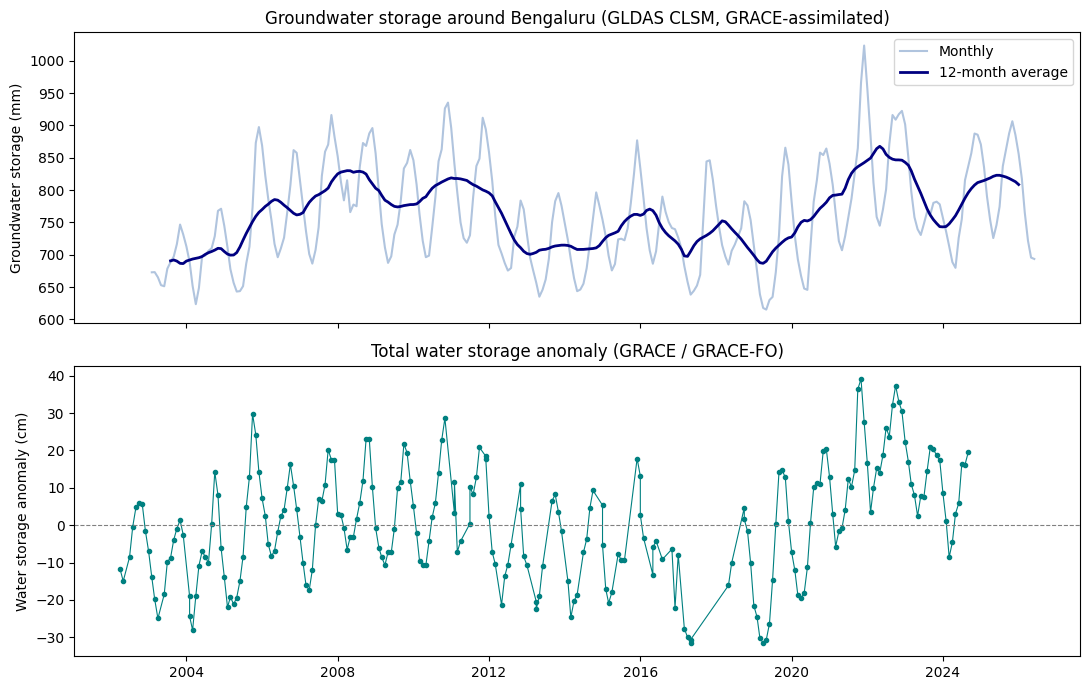

In [15]:
!pip install -q pymannkendall
import pymannkendall as mk

# Area around Bengaluru (30 km radius, needed because the data is coarse)
region = roi.centroid().buffer(30000)

# ---------- 1. GLDAS modelled groundwater storage (mm), GRACE-assimilated ----------
gldas = ee.ImageCollection('NASA/GLDAS/V022/CLSM/G025/DA1D').select('GWS_tavg')
last = ee.Date(gldas.aggregate_max('system:time_start')).format('YYYY-MM').getInfo()
ly, lm = map(int, last.split('-'))
n_months = (ly - 2003) * 12 + lm
print('GLDAS data available up to:', last)

def monthly_gws(i):
    s = ee.Date('2003-01-01').advance(i, 'month')
    img = gldas.filterDate(s, s.advance(1, 'month')).mean()
    v = ee.Dictionary(img.reduceRegion(ee.Reducer.mean(), region, 27830)).get('GWS_tavg', -9999)
    return ee.Feature(None, {'date': s.format('YYYY-MM'), 'gws': v})

gws_df = geemap.ee_to_df(ee.FeatureCollection(
    ee.List.sequence(0, n_months - 1).map(monthly_gws)))
gws_df = gws_df[gws_df['gws'] != -9999].dropna()
gws_df['date'] = pd.to_datetime(gws_df['date'])
gws_df = gws_df.sort_values('date')
print('Months with groundwater data:', len(gws_df))

# ---------- 2. GRACE total water storage anomaly (cm) ----------
grace = ee.ImageCollection('NASA/GRACE/MASS_GRIDS_V04/MASCON_CRI').select('lwe_thickness')

def grace_val(img):
    v = ee.Dictionary(img.reduceRegion(ee.Reducer.mean(), region, 50000)).get('lwe_thickness', -9999)
    return ee.Feature(None, {'date': img.date().format('YYYY-MM'), 'tws': v})

grace_df = geemap.ee_to_df(ee.FeatureCollection(grace.map(grace_val)))
grace_df = grace_df[grace_df['tws'] != -9999].dropna()
grace_df['date'] = pd.to_datetime(grace_df['date'])
grace_df = grace_df.sort_values('date')
print('GRACE data:', grace_df['date'].min().date(), 'to', grace_df['date'].max().date())

# ---------- 3. Trend test on annual averages (removes seasonal ups and downs) ----------
gws_year = gws_df.groupby(gws_df['date'].dt.year)['gws'].mean()
gws_year = gws_year[gws_year.index < ly]          # drop incomplete final year
res = mk.original_test(gws_year.values)
print(f'\nGroundwater storage trend (GLDAS): {res.trend} | '
      f'Sen slope: {res.slope:.1f} mm/year | p-value: {res.p:.4f}')
print(f'Change {gws_year.index[0]}→{gws_year.index[-1]}: '
      f'{gws_year.iloc[-1] - gws_year.iloc[0]:.0f} mm')

# ---------- 4. Plots ----------
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(gws_df['date'], gws_df['gws'], color='lightsteelblue', label='Monthly')
axes[0].plot(gws_df['date'], gws_df['gws'].rolling(12, center=True).mean(),
             color='navy', lw=2, label='12-month average')
axes[0].set_ylabel('Groundwater storage (mm)')
axes[0].set_title('Groundwater storage around Bengaluru (GLDAS CLSM, GRACE-assimilated)')
axes[0].legend()

axes[1].plot(grace_df['date'], grace_df['tws'], color='teal', marker='.', lw=0.8)
axes[1].axhline(0, color='grey', ls='--', lw=0.8)
axes[1].set_ylabel('Water storage anomaly (cm)')
axes[1].set_title('Total water storage anomaly (GRACE / GRACE-FO)')
plt.tight_layout(); plt.show()

        gws  gws_change    rain
date                           
2003  688.6         NaN   749.8
2004  700.6        12.0  1098.5
2005  722.7        22.1  1401.9
2006  781.1        58.4   814.8
2007  792.9        11.8  1258.5
2008  828.6        35.7  1123.9
2009  774.8       -53.8   996.0
2010  802.8        27.9  1346.9
2011  811.4         8.7  1086.5
2012  743.2       -68.2   880.6
2013  708.5       -34.7   958.7
2014  708.3        -0.2  1011.1
2015  744.7        36.4  1079.1
2016  749.7         5.0   644.8
2017  720.5       -29.2  1311.7
2018  734.8        14.3   913.2
2019  704.7       -30.2  1018.3
2020  754.3        49.6  1168.5
2021  816.2        62.0  1358.2
2022  855.2        38.9  1276.1
2023  782.9       -72.2   897.5
2024  778.1        -4.8  1084.1
2025  822.8        44.7  1138.2

Correlation: rainfall vs groundwater CHANGE: 0.38
Correlation: rainfall vs groundwater LEVEL:  0.36


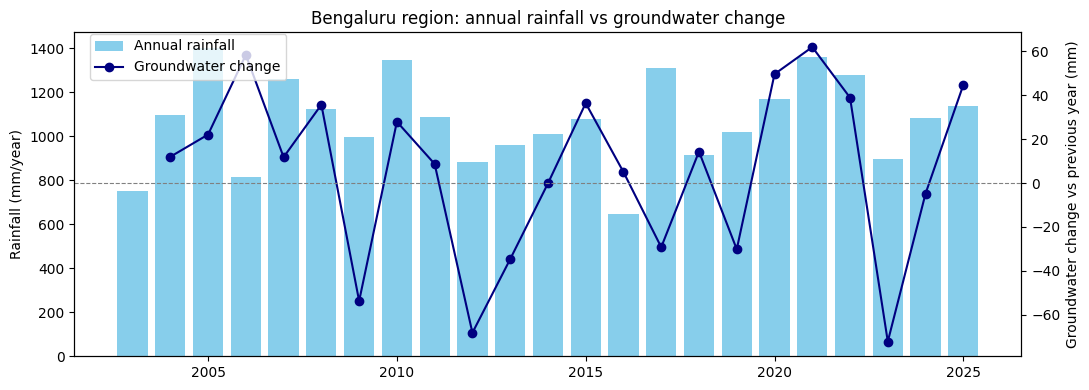

In [16]:
# Annual rainfall from CHIRPS (mm/year) over the same area
chirps = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY').select('precipitation')

def annual_rain(y):
    y = ee.Number(y)
    s = ee.Date.fromYMD(y, 1, 1)
    img = chirps.filterDate(s, s.advance(1, 'year')).sum()
    v = ee.Dictionary(img.reduceRegion(ee.Reducer.mean(), region, 5566)).get('precipitation', -9999)
    return ee.Feature(None, {'year': y, 'rain': v})

rain_df = geemap.ee_to_df(ee.FeatureCollection(
    ee.List(list(range(2003, ly))).map(annual_rain)))
rain_df = rain_df[rain_df['rain'] != -9999].set_index('year')
rain_df.index = rain_df.index.astype(int)

# Combine with groundwater: yearly level and year-to-year change
annual = pd.DataFrame({'gws': gws_year})
annual['gws_change'] = annual['gws'].diff()
annual = annual.join(rain_df, how='inner')

print(annual.round(1).to_string())
print(f"\nCorrelation: rainfall vs groundwater CHANGE: {annual['rain'].corr(annual['gws_change']):.2f}")
print(f"Correlation: rainfall vs groundwater LEVEL:  {annual['rain'].corr(annual['gws']):.2f}")

# Plot: rainfall bars + groundwater change line
fig, ax1 = plt.subplots(figsize=(11, 4))
ax1.bar(annual.index, annual['rain'], color='skyblue', label='Annual rainfall')
ax1.set_ylabel('Rainfall (mm/year)')
ax2 = ax1.twinx()
ax2.plot(annual.index, annual['gws_change'], color='navy', marker='o', label='Groundwater change')
ax2.axhline(0, color='grey', ls='--', lw=0.8)
ax2.set_ylabel('Groundwater change vs previous year (mm)')
plt.title('Bengaluru region: annual rainfall vs groundwater change')
fig.legend(loc='upper left', bbox_to_anchor=(0.08, 0.92))
plt.tight_layout(); plt.show()

Rainfall vs Dec-to-Dec groundwater change:       0.68
Previous year's rainfall vs annual-mean change:  0.25


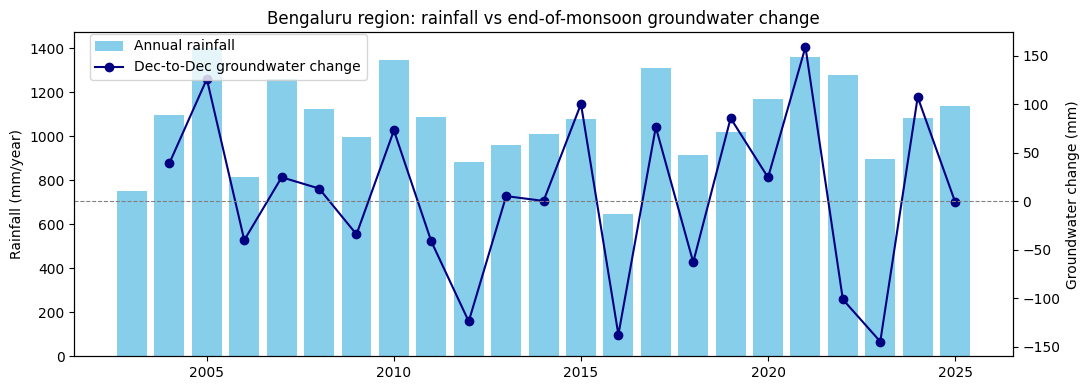

In [17]:
# December-to-December change (captures each monsoon's full effect)
dec = gws_df[gws_df['date'].dt.month == 12].copy()
dec.index = dec['date'].dt.year
annual['dec_change'] = dec['gws'].diff()

print(f"Rainfall vs Dec-to-Dec groundwater change:       {annual['rain'].corr(annual['dec_change']):.2f}")
print(f"Previous year's rainfall vs annual-mean change:  {annual['rain'].shift(1).corr(annual['gws_change']):.2f}")

fig, ax1 = plt.subplots(figsize=(11, 4))
ax1.bar(annual.index, annual['rain'], color='skyblue', label='Annual rainfall')
ax1.set_ylabel('Rainfall (mm/year)')
ax2 = ax1.twinx()
ax2.plot(annual.index, annual['dec_change'], color='navy', marker='o', label='Dec-to-Dec groundwater change')
ax2.axhline(0, color='grey', ls='--', lw=0.8)
ax2.set_ylabel('Groundwater change (mm)')
plt.title('Bengaluru region: rainfall vs end-of-monsoon groundwater change')
fig.legend(loc='upper left', bbox_to_anchor=(0.08, 0.92))
plt.tight_layout(); plt.show()

## Module 4 Findings – Groundwater
- GLDAS (GRACE-assimilated) groundwater storage around Bengaluru, 2003–2025: no significant long-term trend (Mann-Kendall p ≈ 0.11, Sen slope ≈ +2.5 mm/yr).
- GRACE/GRACE-FO total water storage shows the same pattern: lows in 2012–2013 and 2016–2019, a peak in 2021–2022, a sharp drop in 2023.
- End-of-monsoon (Dec-to-Dec) groundwater change correlates strongly with annual rainfall (r ≈ 0.68); a naive calendar-year comparison understates this (r ≈ 0.38) because of recharge timing.
- 2023 (≈898 mm rain) produced one of the largest storage drops, directly preceding the 2024 water crisis.
- Interpretation: the regional water balance is rainfall-driven and recovers in wet years; the local crisis reflects heavy extraction from small hard-rock aquifers and reduced recharge, which satellite data at this scale cannot resolve.

Samples: 8000
R² random split : 0.75
R² spatial split: 0.73  (honest estimate)
RMSE spatial    : 1.65 °C


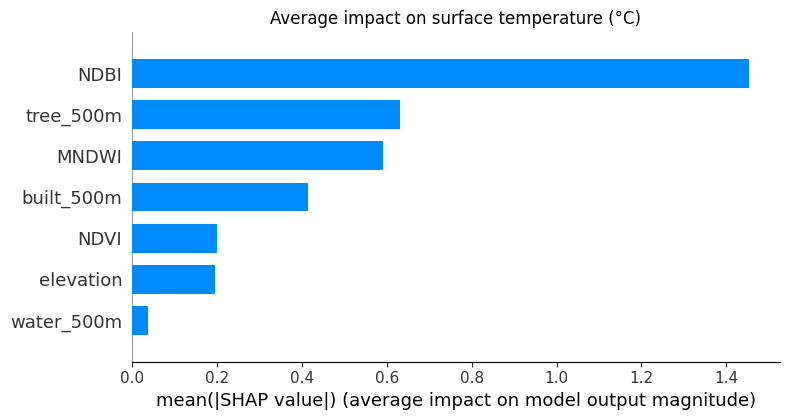

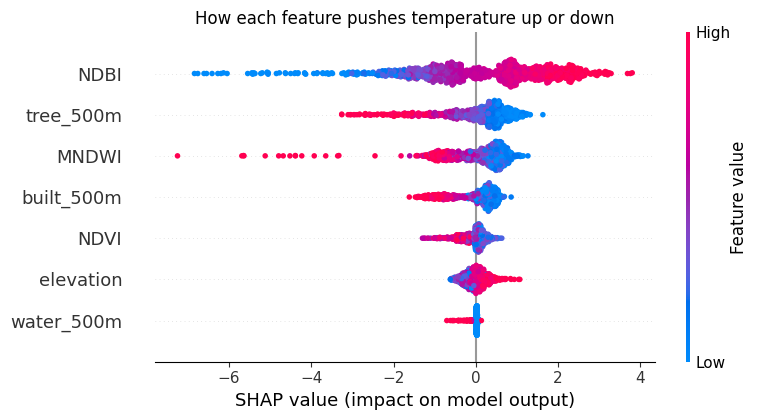

In [19]:
!pip install -q shap
import numpy as np, shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, GroupKFold, cross_val_score

# ---------- 1. Build the feature stack (summer 2024) ----------
def add_mndwi(img):
    sr = img.select(['SR_B3', 'SR_B6']).multiply(0.0000275).add(-0.2)
    return img.addBands(sr.normalizedDifference(['SR_B3', 'SR_B6']).rename('MNDWI'))

summer = (ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')
          .merge(ee.ImageCollection('LANDSAT/LC08/C02/T1_L2'))
          .filterBounds(roi).filterDate('2024-03-01', '2024-05-31')
          .filter(ee.Filter.lt('CLOUD_COVER', 30))
          .map(mask_clouds).map(add_lst).map(add_indices).map(add_mndwi))
spectral = summer.select(['LST', 'NDVI', 'NDBI', 'MNDWI']).median()

def share(cls):
    return wc.eq(cls).focal_mean(radius=500, units='meters')

stack = (spectral
         .addBands(dem.rename('elevation'))
         .addBands(share(50).rename('built_500m'))
         .addBands(share(10).rename('tree_500m'))
         .addBands(share(80).rename('water_500m'))
         .addBands(ee.Image.pixelLonLat())
         .clip(roi))

# ---------- 2. Sample pixels ----------
samples = stack.sample(region=roi, scale=100, numPixels=8000, seed=42, geometries=False)
ml_df = geemap.ee_to_df(samples).dropna()
print('Samples:', len(ml_df))

features = ['NDVI', 'NDBI', 'MNDWI', 'elevation', 'built_500m', 'tree_500m', 'water_500m']
X, y = ml_df[features], ml_df['LST']

# ---------- 3. Random vs spatial cross-validation ----------
rf = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, n_jobs=-1, random_state=42)

r2_random = cross_val_score(rf, X, y, cv=KFold(5, shuffle=True, random_state=42), scoring='r2')
blocks = (ml_df['longitude'] // 0.02).astype(int).astype(str) + '_' + \
         (ml_df['latitude'] // 0.02).astype(int).astype(str)          # ~2 km blocks
r2_spatial = cross_val_score(rf, X, y, cv=GroupKFold(5), groups=blocks, scoring='r2')
rmse_spatial = -cross_val_score(rf, X, y, cv=GroupKFold(5), groups=blocks,
                                scoring='neg_root_mean_squared_error')

print(f'R² random split : {r2_random.mean():.2f}')
print(f'R² spatial split: {r2_spatial.mean():.2f}  (honest estimate)')
print(f'RMSE spatial    : {rmse_spatial.mean():.2f} °C')

# ---------- 4. Fit on all data + SHAP explanation ----------
rf.fit(X, y)
X_explain = X.sample(1000, random_state=42)
shap_values = shap.TreeExplainer(rf).shap_values(X_explain)

shap.summary_plot(shap_values, X_explain, plot_type='bar', show=False)
plt.title('Average impact on surface temperature (°C)'); plt.tight_layout(); plt.show()

shap.summary_plot(shap_values, X_explain, show=False)
plt.title('How each feature pushes temperature up or down'); plt.tight_layout(); plt.show()

Found: /content/e56d21e8-0c44-4c35-9e5d-c732f6f59c97.kml | 2505 KB
Wards loaded: 225
Columns: ['id', 'Name', 'description', 'timestamp', 'begin', 'end', 'altitudeMode', 'tessellate', 'extrude', 'visibility', 'drawOrder', 'icon', 'id2', 'proposed_ward_name_en', 'proposed_ward_name_ka', 'ward_area', 'name_en', 'name_ka', 'population', 'sc_population', 'st_population', 'household', 'male_population', 'female_population', 'assembly_constituency_id', 'assembly_constituency_name_en', 'assembly_constituency_name_ka', 'parliamentary_constituency_id', 'parliamentary_constituency_name_en', 'parliamentary_constituency_name_ka', 'sc_male', 'sc_female', 'st_male', 'st_female', 'bbox', 'geometry']
     id  Name description timestamp begin end altitudeMode  tessellate  \
0  None  None        None       NaT   NaT NaT         None          -1   
1  None  None        None       NaT   NaT NaT         None          -1   
2  None  None        None       NaT   NaT NaT         None          -1   

   extrude

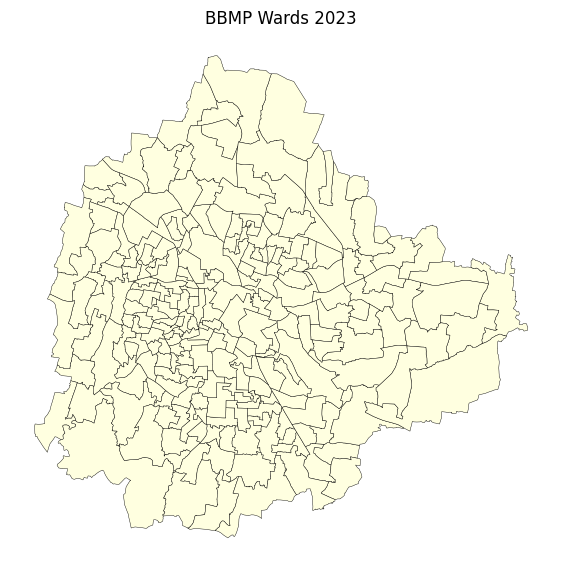

In [20]:
import glob, os, zipfile
import geopandas as gpd

# Find the uploaded file (it has a random ID name)
src = glob.glob('/content/e56d21e8*')[0]
print('Found:', src, '|', round(os.path.getsize(src) / 1024), 'KB')

with open(src, 'rb') as f:
    head = f.read(4)

# KMZ files are zipped KML; unzip if needed
if head.startswith(b'PK'):
    with zipfile.ZipFile(src) as z:
        kml_name = [n for n in z.namelist() if n.endswith('.kml')][0]
        z.extract(kml_name, '/content/kmz_tmp')
    os.rename(f'/content/kmz_tmp/{kml_name}', '/content/bbmp_wards_2023.kml')
else:
    os.rename(src, '/content/bbmp_wards_2023.kml')

wards = gpd.read_file('/content/bbmp_wards_2023.kml')
print('Wards loaded:', len(wards))
print('Columns:', wards.columns.tolist())
print(wards.head(3))

wards.plot(figsize=(7, 7), edgecolor='black', facecolor='lightyellow', linewidth=0.3)
plt.title('BBMP Wards 2023'); plt.axis('off'); plt.show()

Wards with results: 225
 rank                   name_en  vulnerability  lst_day  lst_night  flood  lost_lake_km2  population                           action
    1              Marathahalli           0.66    39.32      24.65   0.55           1.60       40767      Lake restoration & recharge
    2        Kempapura Agrahara           0.60    40.38      27.93   0.66           0.00       36710 Urban greening, Drainage upgrade
    3                HBR Layout           0.59    42.18      27.42   0.61           0.00       42386               Maintain / monitor
    4                Nilasandra           0.58    41.10      27.18   0.65           0.00       39112 Urban greening, Drainage upgrade
    5                  Madivala           0.57    40.39      27.51   0.65           0.00       32659 Urban greening, Drainage upgrade
    6        Silver Jublee Park           0.57    40.94      27.60   0.62           0.00       33453 Urban greening, Drainage upgrade
    7            Dodda Nekkundi       

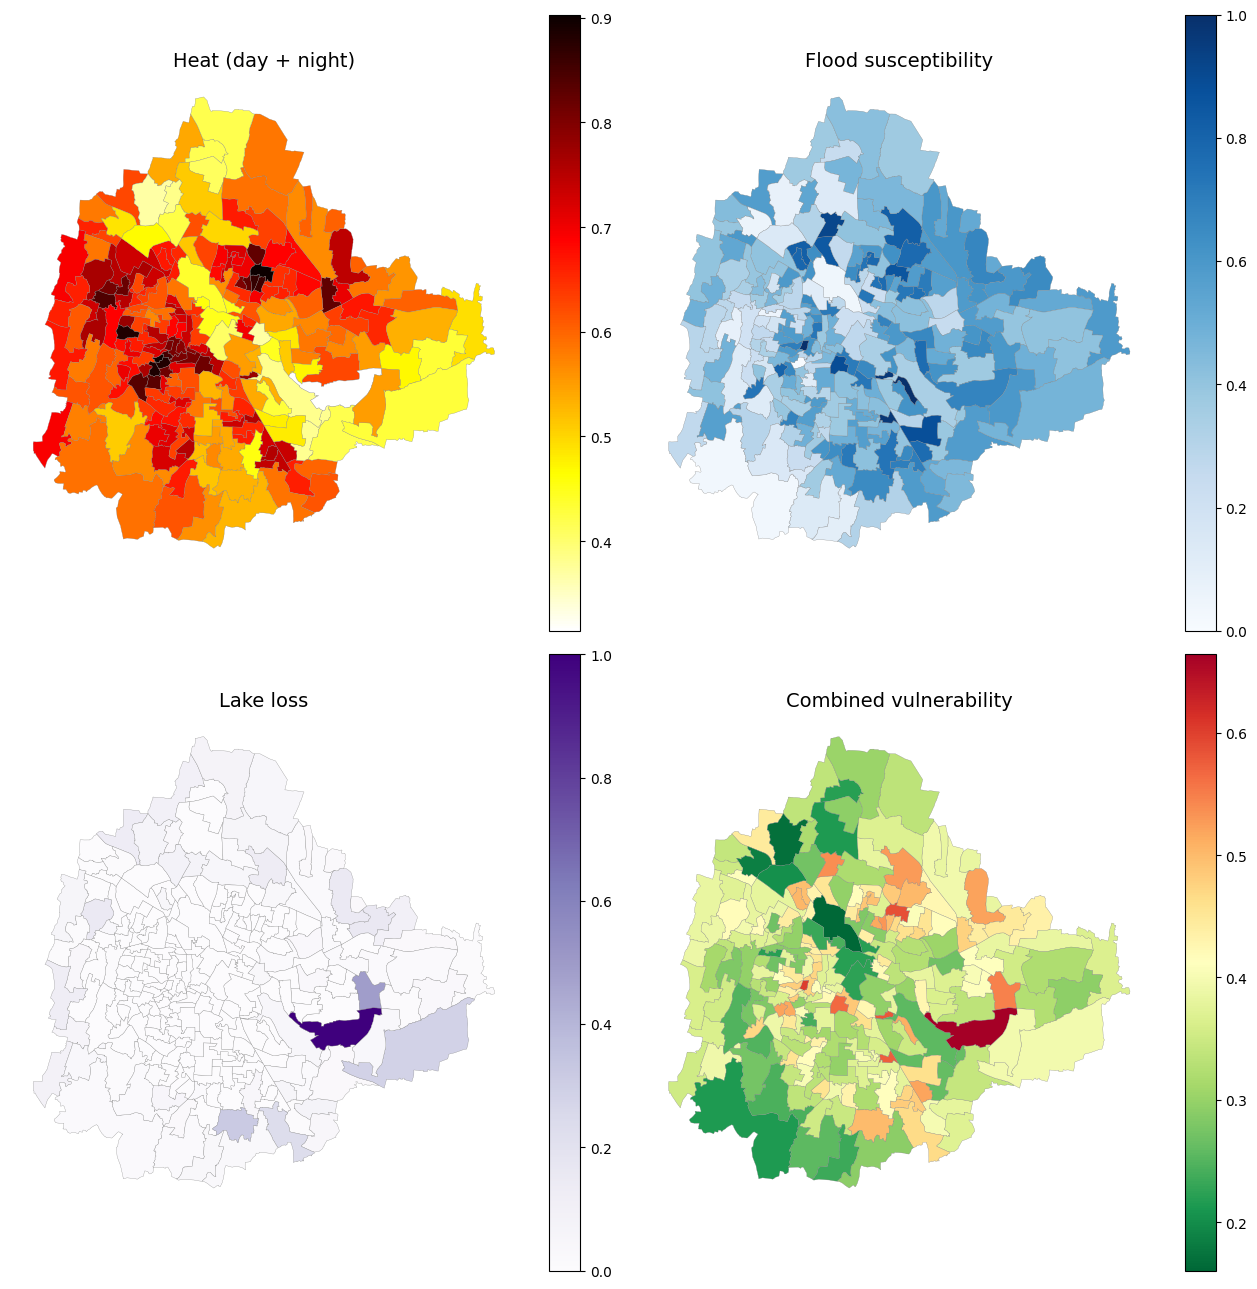

Saved: urbanpulse_wards.geojson


In [21]:
import shapely

# ---------- 1. Prepare wards for Earth Engine ----------
wards['geometry'] = shapely.force_2d(wards.geometry)          # drop 3D coordinates from KML
wards['ward_id'] = range(len(wards))
wards['population'] = pd.to_numeric(wards['population'], errors='coerce')
wards['area_km2'] = wards.to_crs(32643).area / 1e6
wards_ee = geemap.gdf_to_ee(wards[['ward_id', 'name_en', 'geometry']])

# ---------- 2. Stack all indicators ----------
ward_stack = (comp_2024.select('LST').rename('lst_day')
              .addBands(modis_c.select('LST_Night_1km').rename('lst_night'))
              .addBands(susc.rename('flood'))
              .addBands(lost_r.unmask(0).rename('lost_frac'))
              .addBands(wc.eq(10).rename('tree'))
              .addBands(wc.eq(50).rename('built')))

stats = ward_stack.reduceRegions(collection=wards_ee, reducer=ee.Reducer.mean(),
                                 scale=30, tileScale=4)
ward_df = geemap.ee_to_df(stats)
print('Wards with results:', len(ward_df))

# ---------- 3. Merge back and build the index ----------
w = wards[['ward_id', 'name_en', 'population', 'area_km2', 'geometry']].merge(ward_df.drop(columns='name_en'), on='ward_id')
w['lost_lake_km2'] = w['lost_frac'] * w['area_km2']
w['pop_density'] = w['population'] / w['area_km2']

def norm(s):
    return (s - s.min()) / (s.max() - s.min())

w['heat_score']  = (norm(w['lst_day']) + norm(w['lst_night'])) / 2
w['flood_score'] = norm(w['flood'])
w['lake_score']  = norm(w['lost_frac'])
w['vulnerability'] = (w['heat_score'] + w['flood_score'] + w['lake_score']) / 3
w['rank'] = w['vulnerability'].rank(ascending=False).astype(int)

# ---------- 4. Recommended action per ward ----------
q75 = lambda col: w[col].quantile(0.75)
def action(r):
    acts = []
    if r['lost_frac'] >= q75('lost_frac') and r['flood'] >= q75('flood'):
        acts.append('Lake restoration & recharge')
    if r['heat_score'] >= q75('heat_score') and r['tree'] <= w['tree'].quantile(0.25):
        acts.append('Urban greening')
    if r['flood'] >= q75('flood') and r['built'] >= q75('built'):
        acts.append('Drainage upgrade')
    return ', '.join(acts) if acts else 'Maintain / monitor'
w['action'] = w.apply(action, axis=1)

# ---------- 5. Results ----------
top = w.sort_values('rank').head(15)
print(top[['rank', 'name_en', 'vulnerability', 'lst_day', 'lst_night', 'flood',
           'lost_lake_km2', 'population', 'action']].round(2).to_string(index=False))

top20 = w[w['rank'] <= int(len(w) * 0.2)]
print(f"\nTop-20% most vulnerable wards: {len(top20)} wards, "
      f"≈{top20['population'].sum() / 1e5:.1f} lakh people (2011-based ward population)")
print('\nRecommended actions (count of wards):')
print(w['action'].value_counts().to_string())

# ---------- 6. Maps ----------
fig, axes = plt.subplots(2, 2, figsize=(13, 13))
for ax, col, cmap, title in [
        (axes[0, 0], 'heat_score', 'hot_r', 'Heat (day + night)'),
        (axes[0, 1], 'flood_score', 'Blues', 'Flood susceptibility'),
        (axes[1, 0], 'lake_score', 'Purples', 'Lake loss'),
        (axes[1, 1], 'vulnerability', 'RdYlGn_r', 'Combined vulnerability')]:
    w.plot(column=col, cmap=cmap, legend=True, ax=ax, edgecolor='grey', linewidth=0.2)
    ax.set_title(title, fontsize=14); ax.axis('off')
plt.tight_layout(); plt.show()

# ---------- 7. Save for the dashboard ----------
w.to_file('/content/urbanpulse_wards.geojson', driver='GeoJSON')
print('Saved: urbanpulse_wards.geojson')

 rank            name_en  vulnerability  lst_day  lst_night  flood  lost_lake_km2  population                           action
    1    Mangammanapalya           0.80    41.22      26.76   0.58           0.01       40149      Lake restoration & recharge
    2            JP Park           0.80    39.20      27.64   0.59           0.01       42026      Lake restoration & recharge
    3            Kalkere           0.80    42.08      26.24   0.54           0.17       42910      Lake restoration & recharge
    4        Thanisandra           0.80    40.61      26.33   0.60           0.13       37308      Lake restoration & recharge
    5        Kodigehalli           0.78    39.81      26.81   0.63           0.03       40183      Lake restoration & recharge
    6             Hennur           0.78    40.38      26.97   0.58           0.02       36081      Lake restoration & recharge
    7           Hulimavu           0.74    40.73      25.43   0.54           0.29       42690      Lake restora

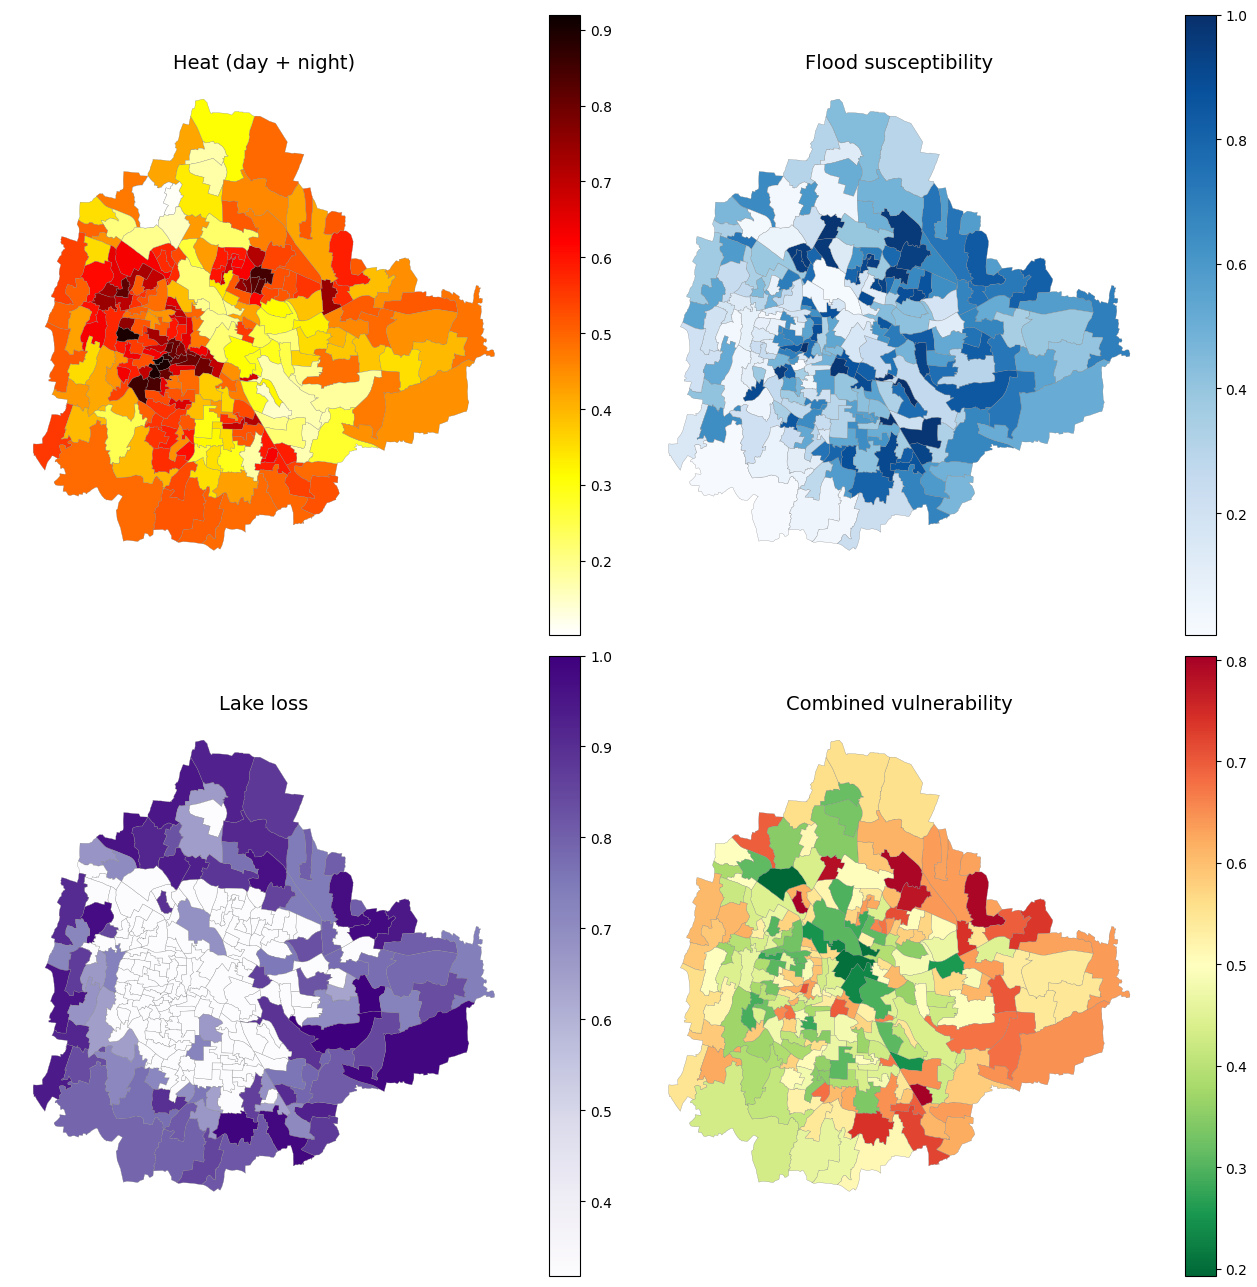

Saved: urbanpulse_wards.geojson


In [22]:
# Rank-based scores (robust to outliers)
def pct(s):
    return s.rank(pct=True)

w['heat_score']  = (pct(w['lst_day']) + pct(w['lst_night'])) / 2
w['flood_score'] = pct(w['flood'])
w['lake_score']  = pct(w['lost_frac'])
w['vulnerability'] = (w['heat_score'] + w['flood_score'] + w['lake_score']) / 3
w['rank'] = w['vulnerability'].rank(ascending=False, method='first').astype(int)
w['action'] = w.apply(action, axis=1)

top = w.sort_values('rank').head(15)
print(top[['rank', 'name_en', 'vulnerability', 'lst_day', 'lst_night', 'flood',
           'lost_lake_km2', 'population', 'action']].round(2).to_string(index=False))

top20 = w[w['rank'] <= int(len(w) * 0.2)]
print(f"\nTop-20% most vulnerable wards: {len(top20)} wards, "
      f"≈{top20['population'].sum() / 1e5:.1f} lakh people (2011-based ward population)")
print(f"Wards with any measurable lake loss: {(w['lost_frac'] > 0.001).sum()} of {len(w)}")

fig, axes = plt.subplots(2, 2, figsize=(13, 13))
for ax, col, cmap, title in [
        (axes[0, 0], 'heat_score', 'hot_r', 'Heat (day + night)'),
        (axes[0, 1], 'flood_score', 'Blues', 'Flood susceptibility'),
        (axes[1, 0], 'lake_score', 'Purples', 'Lake loss'),
        (axes[1, 1], 'vulnerability', 'RdYlGn_r', 'Combined vulnerability')]:
    w.plot(column=col, cmap=cmap, legend=True, ax=ax, edgecolor='grey', linewidth=0.2)
    ax.set_title(title, fontsize=14); ax.axis('off')
plt.tight_layout(); plt.show()

w.to_file('/content/urbanpulse_wards.geojson', driver='GeoJSON')
print('Saved: urbanpulse_wards.geojson')

In [23]:
def action(r):
    acts = []
    if r['lost_lake_km2'] >= 0.05 and r['flood'] >= q75('flood'):
        acts.append('Lake restoration & recharge')
    if r['heat_score'] >= q75('heat_score') and r['tree'] <= w['tree'].quantile(0.25):
        acts.append('Urban greening')
    if r['flood'] >= q75('flood') and r['built'] >= q75('built'):
        acts.append('Drainage upgrade')
    if not acts and r['rank'] <= int(len(w) * 0.2):
        dominant = max(['heat_score', 'flood_score', 'lake_score'], key=lambda c: r[c])
        acts.append({'heat_score': 'Priority: heat mitigation',
                     'flood_score': 'Priority: flood mitigation',
                     'lake_score': 'Priority: lake revival'}[dominant])
    return ', '.join(acts) if acts else 'Maintain / monitor'

w['action'] = w.apply(action, axis=1)

print(w.sort_values('rank').head(15)[['rank', 'name_en', 'vulnerability',
      'lost_lake_km2', 'action']].round(2).to_string(index=False))
print('\nRecommended actions (count of wards):')
print(w['action'].value_counts().to_string())

w.to_file('/content/urbanpulse_wards.geojson', driver='GeoJSON')
print('\nSaved: urbanpulse_wards.geojson')

 rank            name_en  vulnerability  lost_lake_km2                           action
    1    Mangammanapalya           0.80           0.01       Priority: flood mitigation
    2            JP Park           0.80           0.01       Priority: flood mitigation
    3            Kalkere           0.80           0.17      Lake restoration & recharge
    4        Thanisandra           0.80           0.13      Lake restoration & recharge
    5        Kodigehalli           0.78           0.03       Priority: flood mitigation
    6             Hennur           0.78           0.02       Priority: flood mitigation
    7           Hulimavu           0.74           0.29      Lake restoration & recharge
    8         Vijinapura           0.74           0.01           Priority: lake revival
    9       Basavanapura           0.74           0.09      Lake restoration & recharge
   10              Begur           0.72           0.25           Priority: lake revival
   11         HBR Layout        

Wards with meaningful lake loss (≥5 ha): 24
 rank             name_en  vulnerability  lost_lake_km2                           action
    1             Kalkere           0.74           0.17      Lake restoration & recharge
    2            Hulimavu           0.70           0.29      Lake restoration & recharge
    3        Marathahalli           0.68           1.60      Lake restoration & recharge
    4      Dodda Nekkundi           0.68           0.34           Priority: lake revival
    5               Begur           0.67           0.25           Priority: lake revival
    6         Thanisandra           0.67           0.13      Lake restoration & recharge
    7            Varthuru           0.64           1.30           Priority: lake revival
    8          HBR Layout           0.61           0.00       Priority: flood mitigation
    9  Kempapura Agrahara           0.60           0.00 Urban greening, Drainage upgrade
   10  Silver Jublee Park           0.59           0.00 Urban gree

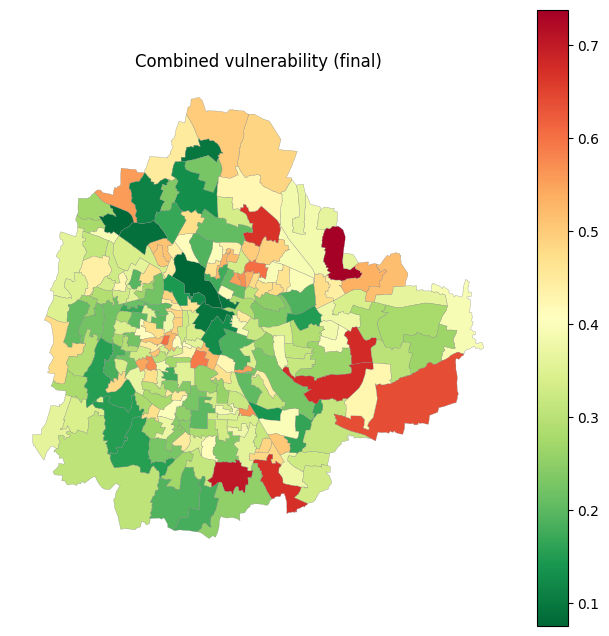

Saved: urbanpulse_wards.geojson


In [24]:
# Lake score: ignore trivial losses, rank only meaningful ones
meaningful = w['lost_lake_km2'] >= 0.05
w['lake_score'] = 0.0
w.loc[meaningful, 'lake_score'] = w.loc[meaningful, 'lost_lake_km2'].rank(pct=True)

w['vulnerability'] = (w['heat_score'] + w['flood_score'] + w['lake_score']) / 3
w['rank'] = w['vulnerability'].rank(ascending=False, method='first').astype(int)
w['action'] = w.apply(action, axis=1)

print(f'Wards with meaningful lake loss (≥5 ha): {meaningful.sum()}')
print(w.sort_values('rank').head(15)[['rank', 'name_en', 'vulnerability',
      'lost_lake_km2', 'action']].round(2).to_string(index=False))

top20 = w[w['rank'] <= int(len(w) * 0.2)]
print(f"\nTop-20% wards: {len(top20)}, ≈{top20['population'].sum() / 1e5:.1f} lakh people")
print('\nRecommended actions:')
print(w['action'].value_counts().to_string())

w.plot(column='vulnerability', cmap='RdYlGn_r', legend=True, figsize=(8, 8),
       edgecolor='grey', linewidth=0.2)
plt.title('Combined vulnerability (final)'); plt.axis('off'); plt.show()

w.to_file('/content/urbanpulse_wards.geojson', driver='GeoJSON')
print('Saved: urbanpulse_wards.geojson')

## Module 6 Findings – Ward Vulnerability Index (225 BBMP wards, 2023 delimitation)
- Per-ward indicators: daytime LST (Landsat), night-time LST (MODIS), flood susceptibility, lost-lake share, tree and built-up cover.
- Vulnerability = equal-weight average of percentile-ranked heat, flood and lake-loss scores (rank-based to avoid one extreme ward dominating).
- Two hotspot clusters: north-east (Mangammanapalya, JP Park, Kalkere, Thanisandra, Kodigehalli, Hennur) and south (Hulimavu, Basavanapura, Begur).
- 69 of 225 wards show measurable lake loss; the 45 most vulnerable wards (top 20%) house ≈17 lakh people (census-based estimate).
- Each ward is tagged with a recommended action: lake restoration, urban greening, drainage upgrade, or a priority based on its dominant risk.

In [25]:
from google.colab import files
files.download('/content/urbanpulse_wards.geojson')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>